# Panatang Makabayan Detector
## Integrated Image + Audio Preprocessing Pipeline

This notebook guides you through:
- Image preparation (noise reduction, color space conversion, normalization, edge/texture/shape features)
- Audio preparation (noise reduction, silence removal, normalization, resampling, segmentation)
- Feature extraction (MFCCs, Spectrograms, Chroma)
- Tandem fusion of image and audio features per 1-second timestamp

---

## Setup

In [6]:
!pip install opencv-python librosa matplotlib numpy


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import cv2
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

print('OpenCV :', cv2.__version__)
print('librosa:', librosa.__version__)
print('NumPy  :', np.__version__)

OpenCV : 4.13.0
librosa: 0.11.0
NumPy  : 2.4.4


---
# PART A — IMAGE PREPARATION

### Engraved Plan

| Step | Operation | Purpose |
|------|-----------|--------|
| 1 | **Noise Reduction** — Gaussian Blur | Suppress sensor noise and lighting flicker |
| 2 | **Color Space Conversion** — BGR to Grayscale | Reduce 3-channel redundancy for analysis |
| 3 | **Normalization** — Min-Max [0, 1] | Equalise per-frame exposure differences |
| 4a | **Edge Features** — Canny | Capture hand/lip boundary sharpness |
| 4b | **Texture Features** — LBP histogram | Encode skin and fabric micro-texture |
| 4c | **Shape Features** — Contour moments | Extract blob area, centroid, aspect ratio |

---

## Load Image

Loaded 11 frames


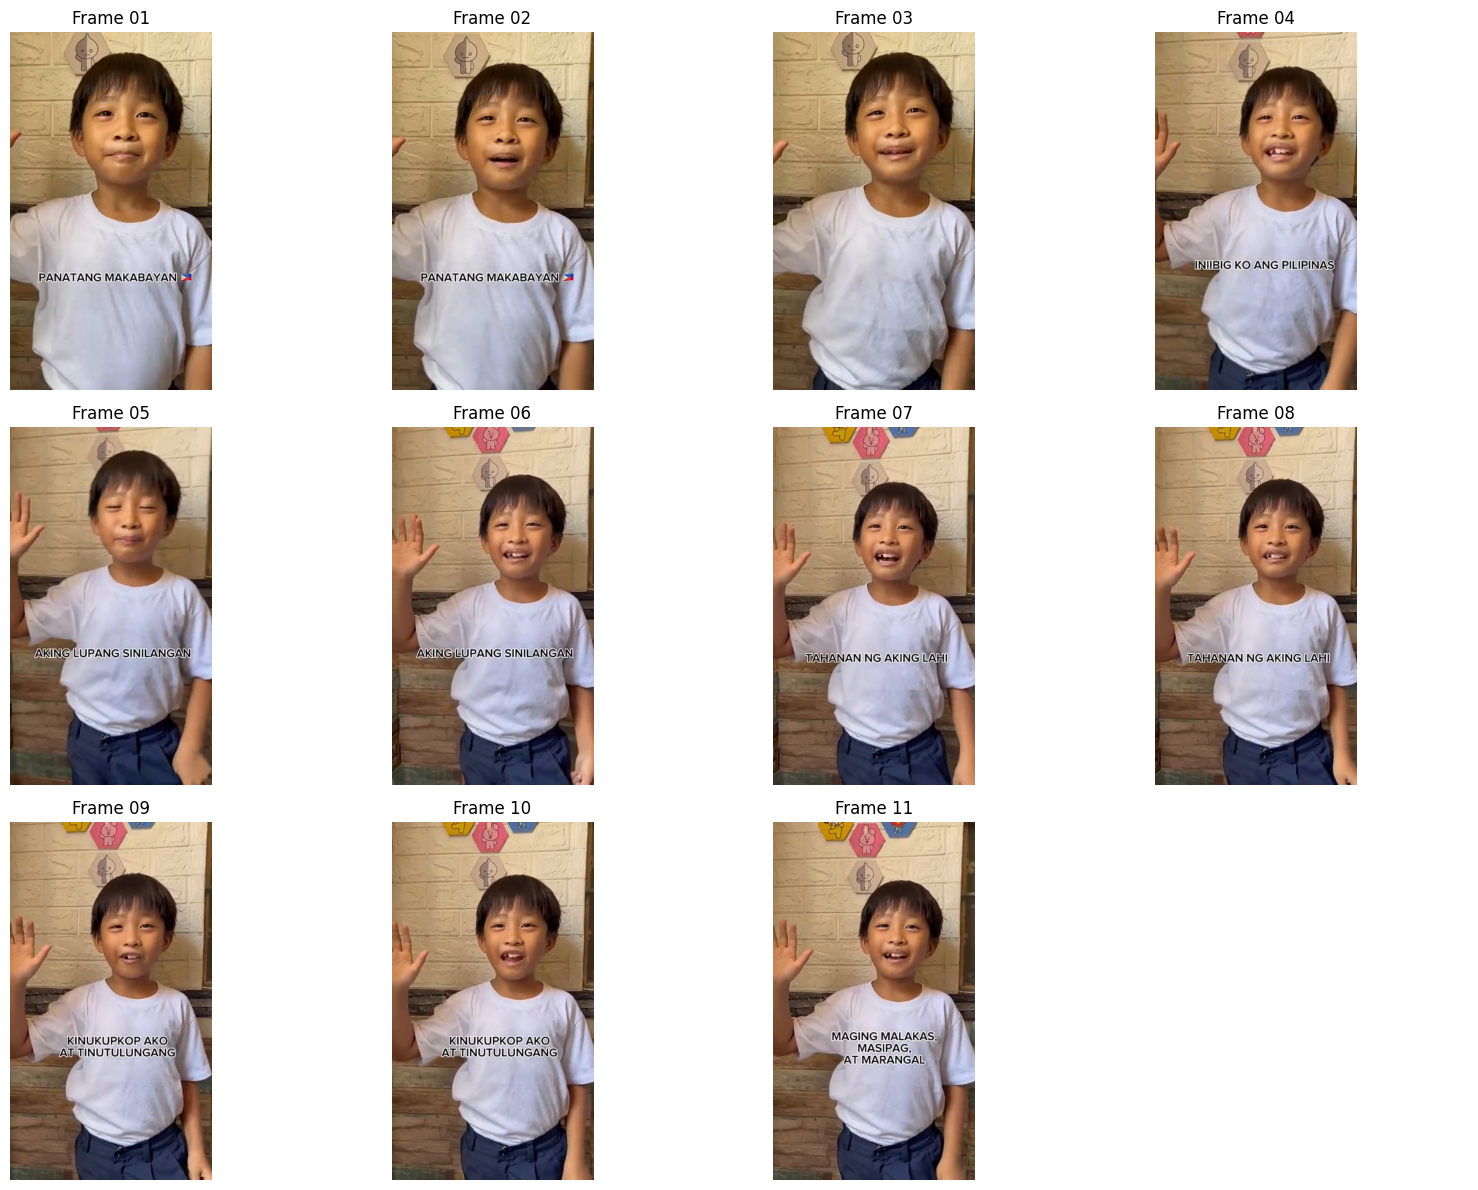

In [9]:
import os

# Load all 11 frames
frames = []
frame_paths = sorted([f for f in os.listdir('frames') if f.endswith('.jpg')])

for frame_file in frame_paths:
    frame = cv2.imread(f'frames/{frame_file}')
    if frame is not None:
        frames.append(frame)

print(f'Loaded {len(frames)} frames')

# Display all original frames in a grid
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, frame in enumerate(frames):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    axes[i].imshow(frame_rgb)
    axes[i].set_title(f'Frame {i+1:02d}')
    axes[i].axis('off')

# Hide the empty 12th subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## Image Preprocessing Loop (All 11 Frames)

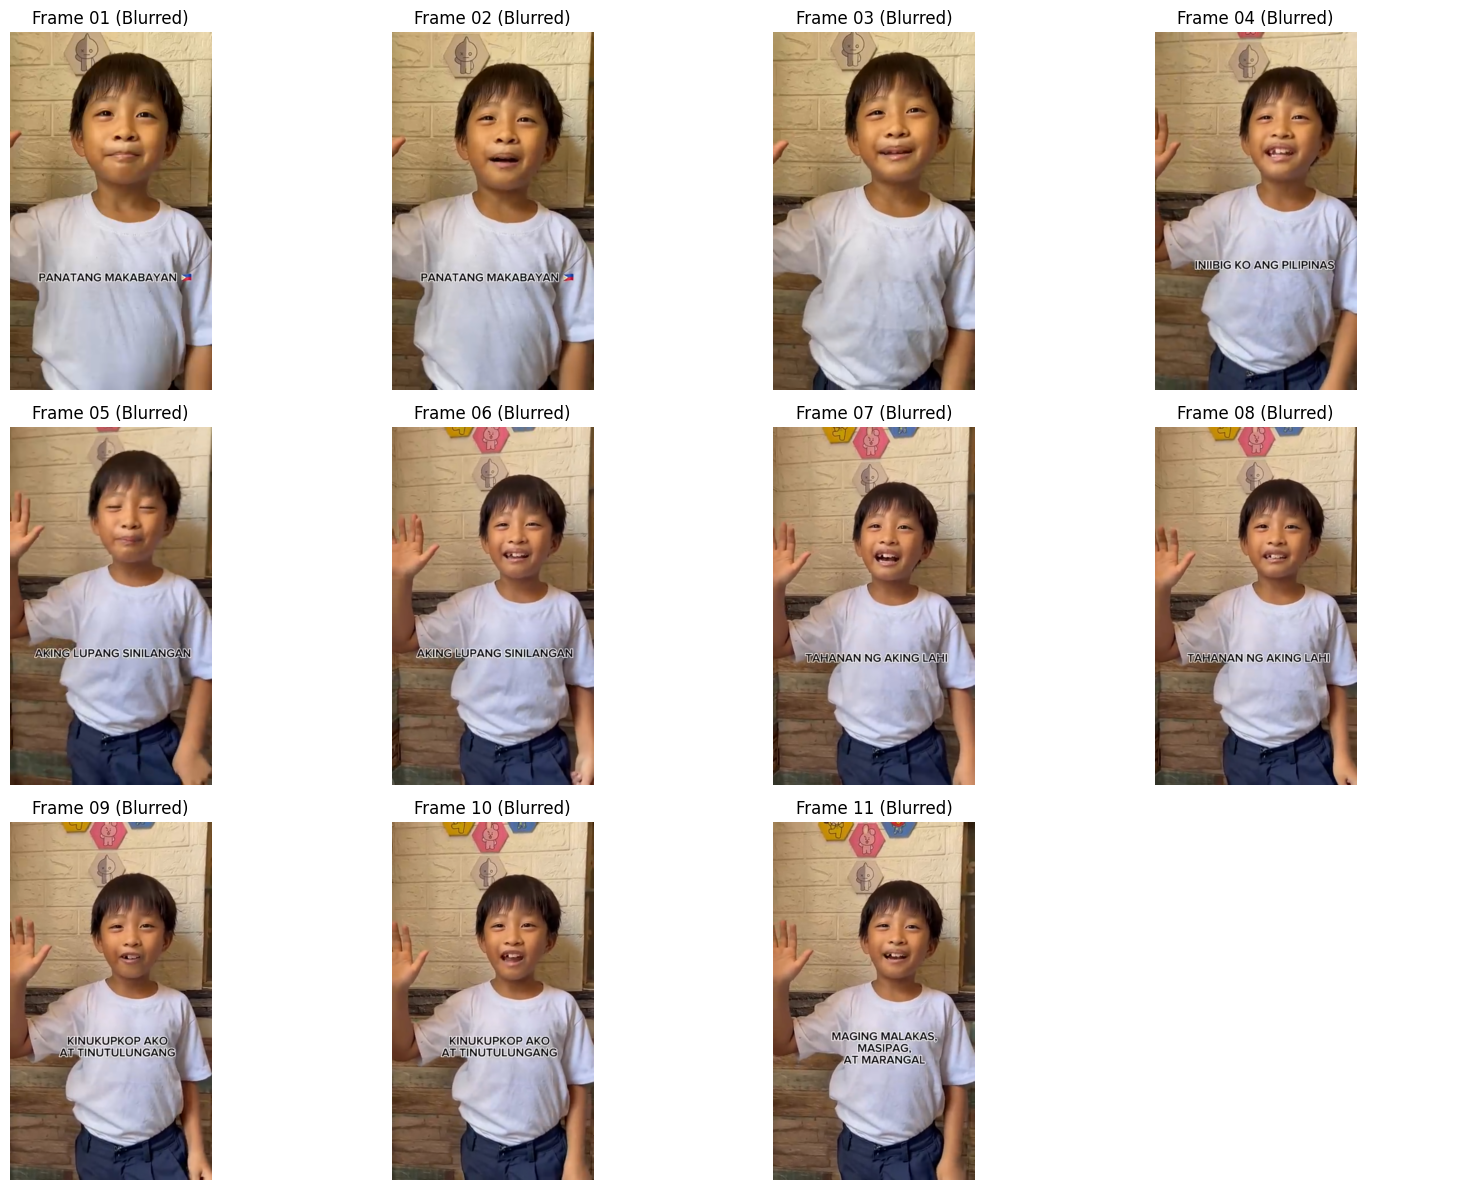

In [ ]:
# Initialize result lists
blurred_frames = []
gray_frames = []
normalized_frames = []
edge_frames = []
lbp_frames = []
contour_frames = []
shape_features = []
lbp_energies = []
lbp_entropies = []

# Define reusable loop function for frame processing
def process_frames(frames_to_process, operation):
    """Apply operation to all frames and return results"""
    results = []
    for i, frame in enumerate(frames_to_process):
        result = operation(frame, i)
        results.append(result)
    return results

print('✓ Loop template ready - will be used in each preprocessing step')

## Image Step 1 — Noise Reduction (Gaussian Blur)

In [ ]:
def blur_operation(frame, i):
    return cv2.GaussianBlur(frame, (5, 5), 0)

blurred_frames = process_frames(frames, blur_operation)

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, blurred in enumerate(blurred_frames):
    axes[i].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Frame {i+1:02d}')
    axes[i].axis('off')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Image Step 2 — Color Space Conversion (BGR to Grayscale)

In [ ]:
def grayscale_operation(frame, i):
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

gray_frames = process_frames(blurred_frames, grayscale_operation)

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, gray in enumerate(gray_frames):
    axes[i].imshow(gray, cmap='gray')
    axes[i].set_title(f'Frame {i+1:02d}')
    axes[i].axis('off')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Image Step 3 — Normalization (Min-Max)

In [ ]:
def normalization_operation(gray, i):
    x_min = gray.min()
    x_max = gray.max()
    return (gray.astype(np.float32) - x_min) / (x_max - x_min + 1e-8)

normalized_frames = process_frames(gray_frames, normalization_operation)

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, norm in enumerate(normalized_frames):
    axes[i].imshow(norm, cmap='gray')
    axes[i].set_title(f'Frame {i+1:02d}')
    axes[i].axis('off')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Image Step 4a — Edge Features (Canny)

In [ ]:
def canny_operation(norm, i):
    norm_u8 = (norm * 255).astype(np.uint8)
    return cv2.Canny(norm_u8, 50, 150)

edge_frames = process_frames(normalized_frames, canny_operation)

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, edges in enumerate(edge_frames):
    axes[i].imshow(edges, cmap='gray')
    axes[i].set_title(f'Frame {i+1:02d}')
    axes[i].axis('off')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Image Step 4b — Texture Features (LBP)

In [ ]:
offsets = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

def lbp_operation(gray, i):
    lbp = np.zeros_like(gray)
    for bit, (dy, dx) in enumerate(offsets):
        M = np.float32([[1, 0, dx], [0, 1, dy]])
        shifted = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]))
        lbp |= ((shifted >= gray).astype(np.uint8) << bit)
    return lbp

lbp_frames = process_frames(gray_frames, lbp_operation)

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, lbp in enumerate(lbp_frames):
    axes[i].imshow(lbp, cmap='gray')
    axes[i].set_title(f'Frame {i+1:02d}')
    axes[i].axis('off')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Image Step 4c — Shape Features (Contour Moments)

In [ ]:
def shape_operation(i):
    edges = edge_frames[i]
    normalized = normalized_frames[i]
    norm_u8 = (normalized * 255).astype(np.uint8)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    contour_img = cv2.cvtColor(norm_u8, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 1)
    
    if contours:
        largest = max(contours, key=cv2.contourArea)
        M = cv2.moments(largest)
        area = M['m00'] / (edges.size + 1e-8)
        cx = (M['m10'] / (M['m00'] + 1e-8)) / edges.shape[1]
        cy = (M['m01'] / (M['m00'] + 1e-8)) / edges.shape[0]
        x, y, bw, bh = cv2.boundingRect(largest)
        aspect = bw / (bh + 1e-8)
    else:
        area, cx, cy, aspect = 0.0, 0.5, 0.5, 1.0
    
    return {'contour_img': contour_img, 'features': {'area': area, 'cx': cx, 'cy': cy, 'aspect': aspect}}

# Process all frames
contour_frames = []
shape_features = []
for i in range(len(frames)):
    result = shape_operation(i)
    contour_frames.append(result['contour_img'])
    shape_features.append(result['features'])

# Visualize
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
for i, contour_img in enumerate(contour_frames):
    axes[i].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Frame {i+1:02d}')
    axes[i].axis('off')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print('✓ Part A preprocessing complete!')

---
# PART B — AUDIO PREPARATION

### Engraved Plan

| Step | Operation | Purpose |
|------|-----------|--------|
| 1 | **Noise Reduction** — Spectral floor gate | Remove broadband background hiss |
| 2 | **Silence Removal** — librosa.effects.trim | Eliminate gaps between pledge lines |
| 3 | **Normalization** — Peak amplitude | Bring amplitude to [-1, 1] regardless of mic gain |
| 4 | **Resampling** — librosa.resample to 22050 Hz | Standardise sample rate across all recordings |
| 5 | **Segmentation** — 11 equal windows | Lock each audio chunk to its matching image frame |
| 6 | **MFCC** — librosa.feature.mfcc | Compact spectral envelope descriptor for speech |
| 7 | **Spectrogram** — STFT magnitude to dB | Time-frequency map for visual inspection |
| 8 | **Chroma** — librosa.feature.chroma_stft | Tonal/pitch accent in the recitation |

---

## Load Audio

Sample Rate: 44100
Duration   : 10.03 seconds


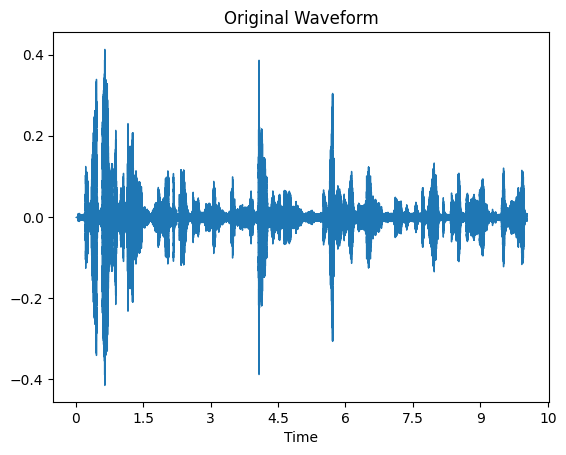

In [16]:
audio_path = 'PANATANG MAKABAYAN.wav'
signal, sr = librosa.load(audio_path, sr=None)

print('Sample Rate:', sr)
print('Duration   :', round(len(signal) / sr, 2), 'seconds')

plt.figure()
librosa.display.waveshow(signal, sr=sr)
plt.title('Original Waveform')
plt.show()

## Audio Step 1 — Noise Reduction (Spectral Floor Gate)

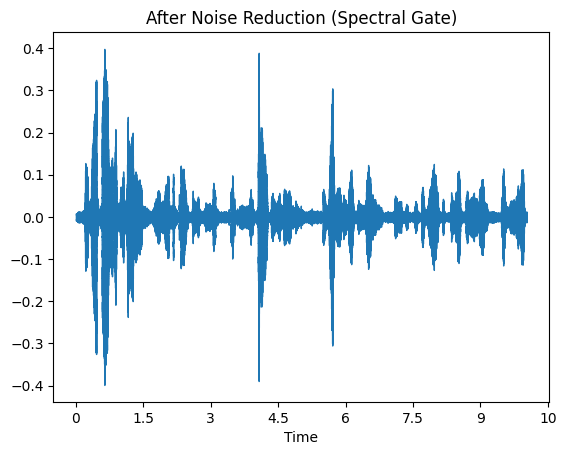

In [17]:
# Zero out DFT bins below the noise floor (mean + 0.5 std of magnitude spectrum)
fft_full  = np.fft.rfft(signal)
magnitude = np.abs(fft_full)
threshold = magnitude.mean() + 0.5 * magnitude.std()
fft_gated = np.where(magnitude >= threshold, fft_full, 0)
denoised  = np.fft.irfft(fft_gated, n=len(signal)).astype(np.float32)

plt.figure()
librosa.display.waveshow(denoised, sr=sr)
plt.title('After Noise Reduction (Spectral Gate)')
plt.show()

## Audio Step 2 — Silence Removal

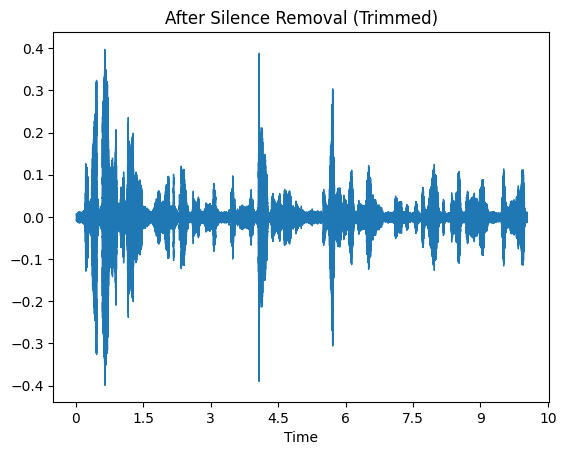

Duration before trim: 10.03 s
Duration after trim : 10.03 s


In [18]:
trimmed, _ = librosa.effects.trim(denoised, top_db=40)

plt.figure()
librosa.display.waveshow(trimmed, sr=sr)
plt.title('After Silence Removal (Trimmed)')
plt.show()

print('Duration before trim:', round(len(denoised) / sr, 2), 's')
print('Duration after trim :', round(len(trimmed) / sr, 2), 's')

## Audio Step 3 — Normalization

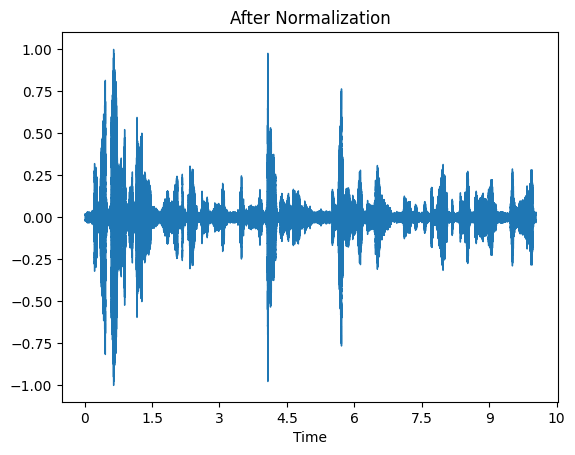

Peak amplitude: 1.0


In [19]:
normalized_audio = librosa.util.normalize(trimmed)

plt.figure()
librosa.display.waveshow(normalized_audio, sr=sr)
plt.title('After Normalization')
plt.show()

print('Peak amplitude:', round(float(np.max(np.abs(normalized_audio))), 4))

## Audio Step 4 — Resampling

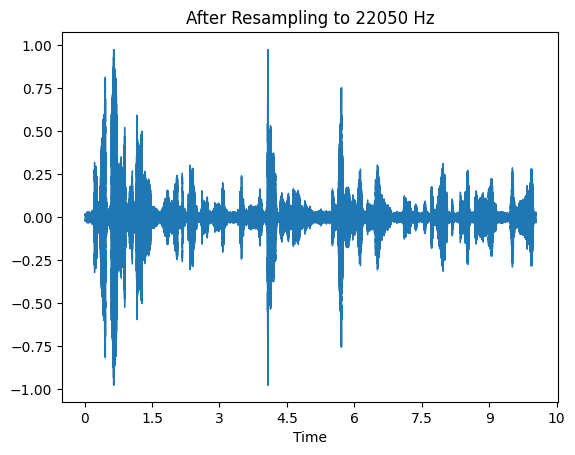

Original SR: 44100 Target SR: 22050
New length : 221208 samples


In [20]:
TARGET_SR = 22050
resampled = librosa.resample(normalized_audio, orig_sr=sr, target_sr=TARGET_SR)

plt.figure()
librosa.display.waveshow(resampled, sr=TARGET_SR)
plt.title('After Resampling to 22050 Hz')
plt.show()

print('Original SR:', sr, 'Target SR:', TARGET_SR)
print('New length :', len(resampled), 'samples')

## Audio Step 5 — Segmentation (11 Windows)

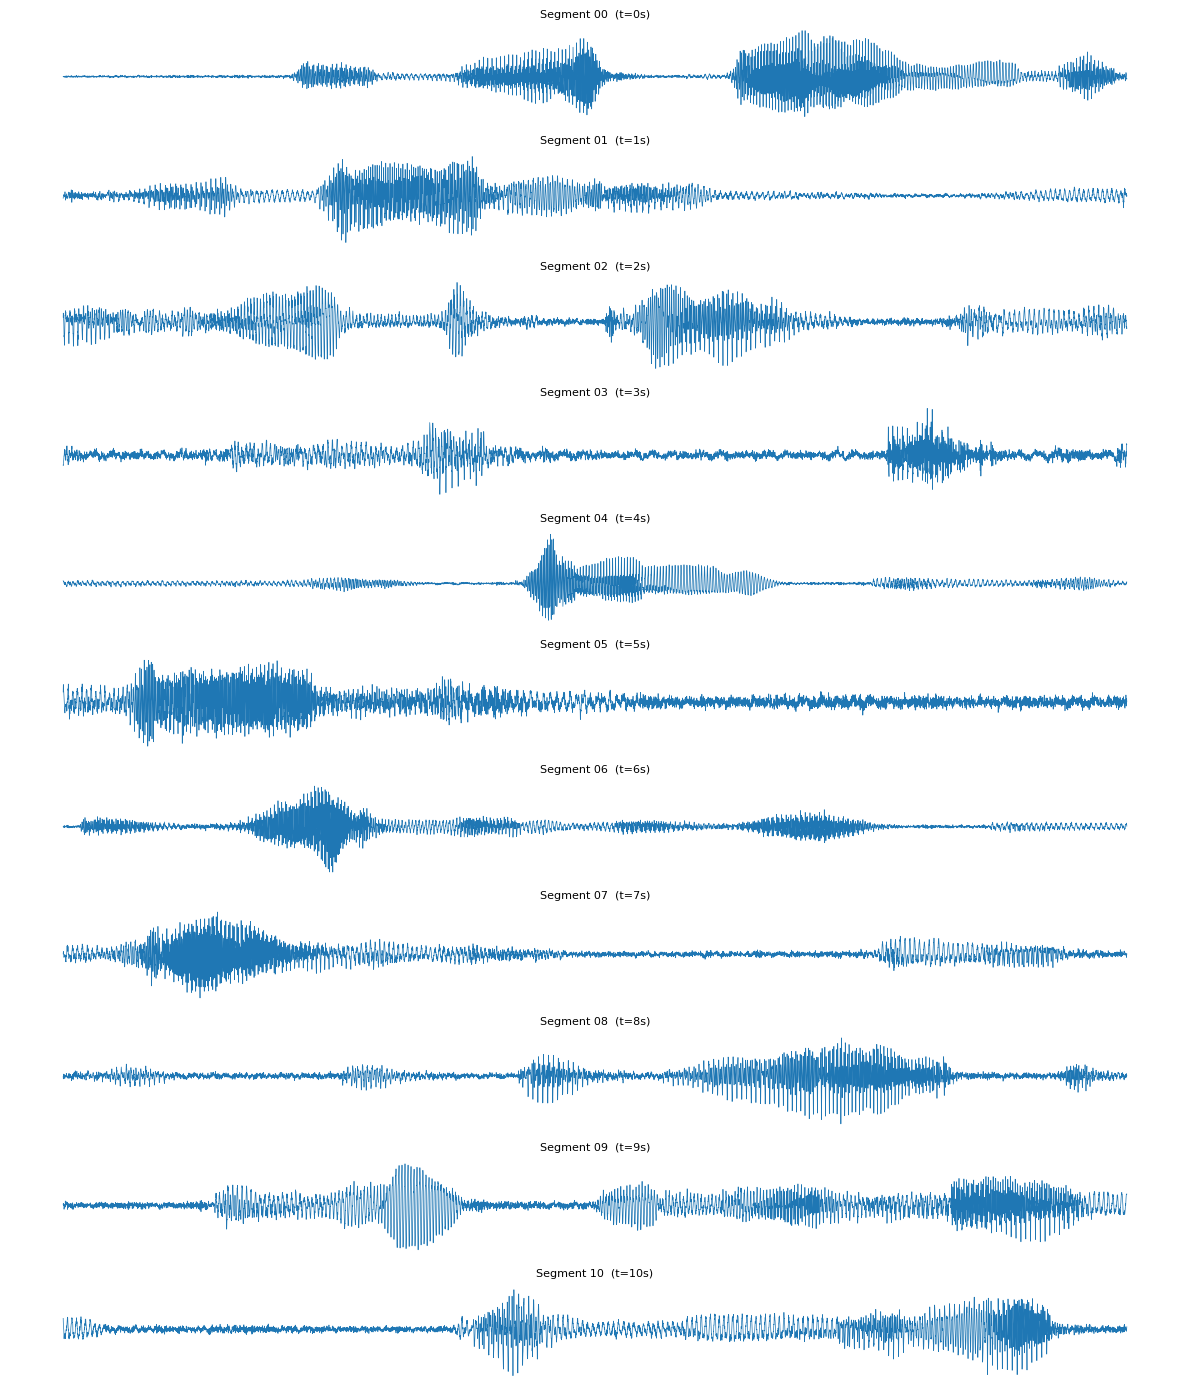

Segments: 11   Samples each: 20109


In [21]:
NUM_SEGMENTS = 11
seg_len = len(resampled) // NUM_SEGMENTS
segments = [resampled[i * seg_len : (i + 1) * seg_len] for i in range(NUM_SEGMENTS)]

fig, axes = plt.subplots(NUM_SEGMENTS, 1, figsize=(12, 14))
for i, seg in enumerate(segments):
    axes[i].plot(seg, linewidth=0.5)
    axes[i].set_title(f'Segment {i:02d}  (t={i}s)', fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

print('Segments:', len(segments), '  Samples each:', seg_len)

---
# PART C — FEATURE EXTRACTION

---

## Feature Step 6 — MFCC

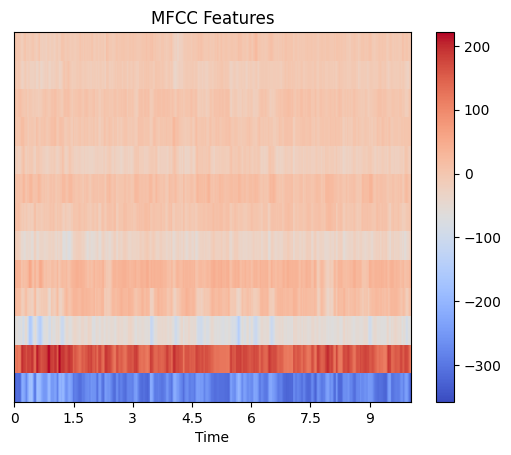

MFCC Shape: (13, 433)


In [22]:
mfccs = librosa.feature.mfcc(y=resampled, sr=TARGET_SR, n_mfcc=13)

plt.figure()
librosa.display.specshow(mfccs, sr=TARGET_SR, x_axis='time')
plt.colorbar()
plt.title('MFCC Features')
plt.show()

print('MFCC Shape:', mfccs.shape)

## Feature Step 7 — Spectrogram

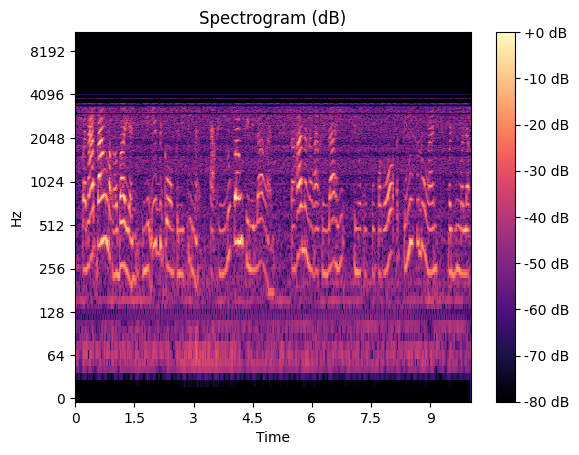

Spectrogram Shape: (1025, 433)


In [23]:
spectrogram = np.abs(librosa.stft(resampled))
spec_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

plt.figure()
librosa.display.specshow(spec_db, sr=TARGET_SR, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (dB)')
plt.show()

print('Spectrogram Shape:', spec_db.shape)

## Feature Step 8 — Chroma

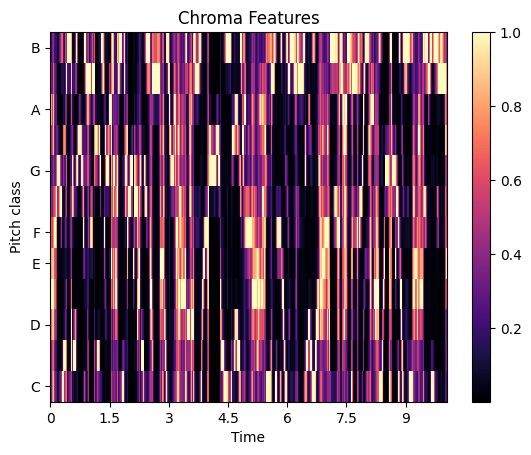

Chroma Shape: (12, 433)


In [24]:
chroma = librosa.feature.chroma_stft(y=resampled, sr=TARGET_SR)

plt.figure()
librosa.display.specshow(chroma, sr=TARGET_SR, x_axis='time', y_axis='chroma')
plt.colorbar()
plt.title('Chroma Features')
plt.show()

print('Chroma Shape:', chroma.shape)

## Save Outputs

In [ ]:
import os

# Create output directory
output_dir = 'preprocessed_output'
os.makedirs(output_dir, exist_ok=True)

print('=== SAVING PREPROCESSED OUTPUT ===\n')

# Save images
for i, frame in enumerate(frames):
    cv2.imwrite(f'{output_dir}/frame_{i+1:02d}_original.jpg', frame)
print(f'✓ Saved {len(frames)} original frames')

for i, gray in enumerate(gray_frames):
    cv2.imwrite(f'{output_dir}/frame_{i+1:02d}_grayscale.jpg', gray)
print(f'✓ Saved {len(gray_frames)} grayscale frames')

for i, edges in enumerate(edge_frames):
    cv2.imwrite(f'{output_dir}/frame_{i+1:02d}_edges.png', edges)
print(f'✓ Saved {len(edge_frames)} edge frames')

for i, lbp in enumerate(lbp_frames):
    cv2.imwrite(f'{output_dir}/frame_{i+1:02d}_lbp.png', lbp)
print(f'✓ Saved {len(lbp_frames)} LBP frames')

# Save audio
np.save(f'{output_dir}/audio_preprocessed.npy', resampled.astype(np.float32))
print(f'✓ Saved preprocessed audio ({len(resampled)} samples @ {TARGET_SR} Hz)')

for i, seg in enumerate(segments):
    np.save(f'{output_dir}/audio_segment_{i+1:02d}.npy', seg.astype(np.float32))
print(f'✓ Saved {len(segments)} audio segments')

print(f'\n✅ All preprocessing outputs saved to: {output_dir}/')

=== OUTPUTS SAVED ===

✓ sample_preprocessed/frames_edges/     (11 edge PNG files)
✓ sample_preprocessed/features/img_features.npy    (11, 8)
✓ sample_preprocessed/features/aud_features.npy    (11, 6)
✓ sample_preprocessed/features/fused_features.npy  (11, 14)

Dataset ready for confidence prediction model!
